# 03 Bus Annual Simulation

This notebook moves the bus model from one representative block day to a dated feed-year simulation. The current GTFS timetable covers `2026-04-17` to `2027-04-16`, so this is a feed-year model, not a 2025 calendar-year model. SOC is carried continuously across days, and inactive days are represented as all-day `depot_terminus` dwell so charging can recover between service days.

In [1]:
import importlib
import inspect
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

NOTEBOOK_START = time.time()
NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR.parent / "mobility").exists() else NOTEBOOK_DIR
if not (REPO_ROOT / "mobility").exists():
    REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

expected_mobility_dir = (REPO_ROOT / "mobility").resolve()
loaded_mobility = sys.modules.get("mobility")
if loaded_mobility is not None:
    loaded_file_raw = getattr(loaded_mobility, "__file__", None)
    loaded_file = Path(loaded_file_raw).resolve() if loaded_file_raw else None
    if loaded_file is None or loaded_file.parent != expected_mobility_dir:
        for module_name in list(sys.modules):
            if module_name == "mobility" or module_name.startswith("mobility."):
                del sys.modules[module_name]

import mobility.bus as _bus_module
import mobility.bus.annual_simulation as _annual_simulation

importlib.reload(_annual_simulation)
importlib.reload(_bus_module)

from mobility.core.simulator import STEP_HOURS, STEPS_PER_DAY
from mobility.bus import (
    FEED_YEAR_END,
    FEED_YEAR_START,
    attach_lsoa,
    build_service_date_index,
    load_all_blocks,
    load_bus_vehicle_params,
    load_service_calendar,
    sample_bus_vehicle_specs,
    simulate_block_year,
    simulate_fleet_year,
    write_annual_results,
)

if "warm_up_days" not in inspect.signature(simulate_block_year).parameters:
    raise RuntimeError(
        "simulate_block_year was imported without warm_up_days support. "
        "Restart the kernel and rerun the setup cell; loaded function: "
        f"{simulate_block_year}"
    )

BLOCKS_PATH = REPO_ROOT / "outputs" / "all_blocks.parquet"
VEHICLE_PARAMS_PATH = REPO_ROOT.parent / "Data" / "EV" / "EV_prepared" / "BEV_Bus_Coach_unique_with_params_with_AC.csv"
BUS_ANNUAL_SMOKE_PER_BLOCK_PATH = REPO_ROOT / "outputs" / "bus_annual_smoke_per_block.parquet"
BUS_ANNUAL_SMOKE_LOAD_PROFILE_PATH = REPO_ROOT / "outputs" / "bus_annual_smoke_load_profile.parquet"
MAIN_BUS_ANNUAL_SEED = 20260505

plt.rcParams["figure.figsize"] = (12, 4.5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## A. Feed-Year Calendar

D:\OneDrive - University of Exeter\Projects\Nature_EV_2025\Modelling\mobility\bus\data_loader.py:163: RuntimeWarning: Boundary file missing, skipping Scotland_DZ2022: D:\OneDrive - University of Exeter\Projects\Nature_EV_2025\Data\Loads\SG_DataZone_Bdry_2022.geojson
  polygon_index = load_lsoa_boundary_index()


,metric,value
0,feed_year_start,2026-04-17
1,feed_year_end,2027-04-16
2,gtfs_calendar_services,2368
3,gtfs_exception_services,3556
4,block_services,4068
5,services_active_in_feed_year,3946
6,services_active_in_2025,0


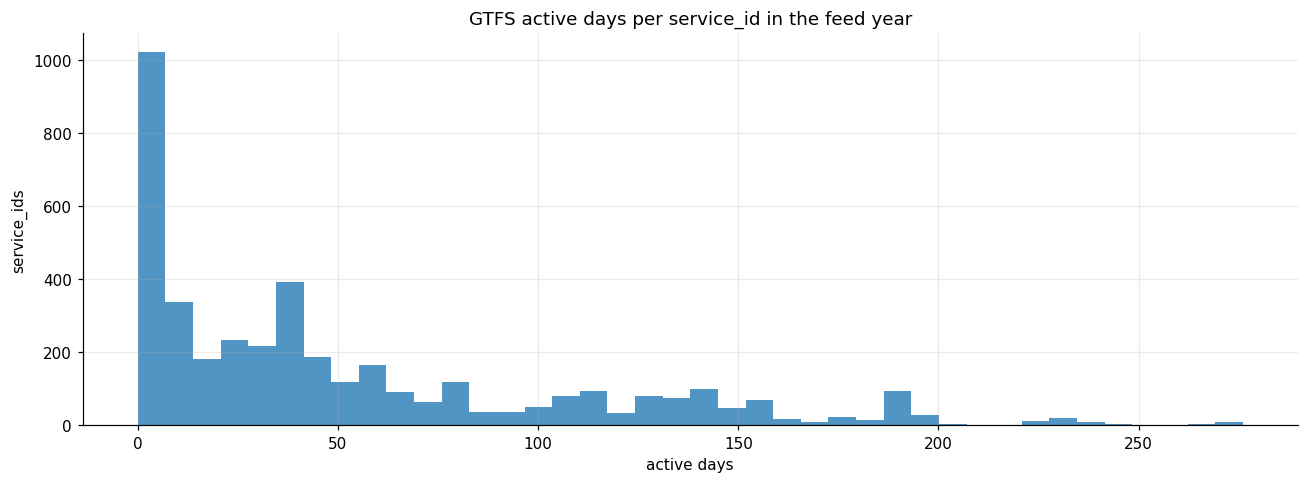

In [2]:
all_blocks = attach_lsoa(load_all_blocks(BLOCKS_PATH))
service_calendar = load_service_calendar()
service_date_index = build_service_date_index(
    all_blocks["service_id"].astype(str).unique(),
    FEED_YEAR_START,
    FEED_YEAR_END,
    service_calendar,
)
active_days_by_service = pd.Series(
    {service_id: len(dates) for service_id, dates in service_date_index.items()},
    name="active_days",
)
display(
    pd.DataFrame(
        [
            ("feed_year_start", FEED_YEAR_START.isoformat()),
            ("feed_year_end", FEED_YEAR_END.isoformat()),
            ("gtfs_calendar_services", service_calendar.calendar["service_id"].nunique()),
            ("gtfs_exception_services", service_calendar.calendar_dates["service_id"].nunique()),
            ("block_services", all_blocks["service_id"].nunique()),
            ("services_active_in_feed_year", int((active_days_by_service > 0).sum())),
            ("services_active_in_2025", 0),
        ],
        columns=["metric", "value"],
    )
)

fig, ax = plt.subplots(figsize=(12, 4.5), dpi=110)
ax.hist(active_days_by_service, bins=40, color="tab:blue", alpha=0.78)
ax.set(title="GTFS active days per service_id in the feed year", xlabel="active days", ylabel="service_ids")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## B. Pick a Protagonist Block

In [3]:
rng = np.random.default_rng(MAIN_BUS_ANNUAL_SEED)
block_stats = all_blocks.groupby("block_id", sort=False).agg(
    agency_id=("agency_id", "first"),
    service_id=("service_id", "first"),
    block_source=("block_source", "first"),
    n_trips=("trip_id", "count"),
    total_km=("distance_km", "sum"),
    start_h=("start_h", "min"),
    end_h=("end_h", "max"),
)
block_stats["active_days"] = block_stats["service_id"].astype(str).map(active_days_by_service).fillna(0).astype(int)
candidates = block_stats[
    block_stats["active_days"].gt(0)
    & block_stats["block_source"].eq("native")
    & block_stats["total_km"].between(40.0, 250.0)
].sort_index()
protagonist_id = str(candidates.index[int(rng.integers(0, len(candidates)))])
protagonist_block = all_blocks[all_blocks["block_id"].astype(str).eq(protagonist_id)].copy()
protagonist_service_id = str(protagonist_block["service_id"].iloc[0])
protagonist_active_dates = service_date_index[protagonist_service_id]

vehicle_params = load_bus_vehicle_params(VEHICLE_PARAMS_PATH)
protagonist_vehicle = sample_bus_vehicle_specs(vehicle_params, rng, n=1).iloc[0]
display(block_stats.loc[[protagonist_id]])
display(pd.DataFrame([protagonist_vehicle]))

,agency_id,service_id,block_source,n_trips,total_km,start_h,end_h,active_days
block_id,,,,,,,,
9a540161c4bf3491ae06d557d91e9c1aaf7fcef7,OP12112,25070,native,10,211.219055,6.666667,18.716667,190


,sample_id,make,gen_model,stock_2025_q2,battery_kwh,consumption_kwh_per_km,depot_charge_kw,source_url,subtype
0,0,VOLVO,VOLVO BE,480.0,470.0,1.26,250.0,https://www.zemo.org.uk/work-with-us/buses-coa...,bus


## C. Single Block Annual SOC

,metric,value
0,active_days,190.0000
1,annual_distance_km,40131.6200
2,annual_energy_kwh,50565.8400
3,energy_charged_kwh,50565.8400
4,soc_min,0.4486
5,soc_end,1.0000


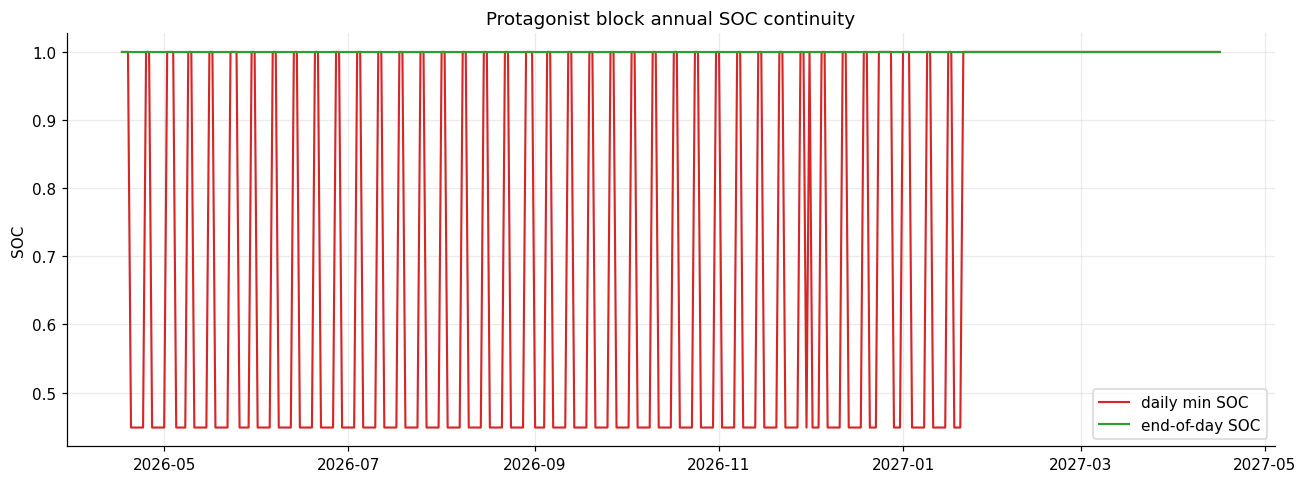

In [4]:
protagonist_result = simulate_block_year(
    protagonist_block,
    protagonist_active_dates,
    protagonist_vehicle,
    FEED_YEAR_START,
    FEED_YEAR_END,
    soc_init=1.0,
    warm_up_days=0,
)
display(
    pd.DataFrame(
        [
            ("active_days", protagonist_result["active_days"]),
            ("annual_distance_km", round(protagonist_result["annual_distance_km"], 2)),
            ("annual_energy_kwh", round(protagonist_result["annual_energy_kwh"], 2)),
            ("energy_charged_kwh", round(protagonist_result["energy_charged_kwh"], 2)),
            ("soc_min", round(protagonist_result["soc_min"], 4)),
            ("soc_end", round(protagonist_result["soc_end"], 4)),
        ],
        columns=["metric", "value"],
    )
)

dates = pd.date_range(FEED_YEAR_START, FEED_YEAR_END, freq="D")
soc_days = protagonist_result["soc"].reshape(len(dates), STEPS_PER_DAY)
fig, ax = plt.subplots(figsize=(12, 4.5), dpi=110)
ax.plot(dates, soc_days.min(axis=1), color="tab:red", lw=1.4, label="daily min SOC")
ax.plot(dates, soc_days[:, -1], color="tab:green", lw=1.4, label="end-of-day SOC")
ax.set(title="Protagonist block annual SOC continuity", ylabel="SOC")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## D. Small Fleet Annual Load

  Simulated annual bus blocks: 4/4


,agency_id,service_id,active_days,annual_distance_km,annual_energy_kwh,soc_min,vehicle_gen_model
block_id,,,,,,,
51af26c34d59a97f656d0849b884e4d0a1d943f6,OP12112,56,39,7931.310159,5313.977806,0.712107,ALEXANDER DENNIS ENVIRO
66e6347c0ceb614ab98a76a07f85bb3a6332ab71,OP12112,374,43,1838.636049,1489.295200,0.924805,WRIGHTBUS STREETDECK
72335416c44fdaa19d5c4bdafe73c50a779f90b4,OP688,6419,37,6733.339024,4511.337146,0.661252,BYD ENVIRO
1de96596fc4583813b85857c81c36311d548cdf2,OP83,98,188,20829.394035,16871.809169,0.808571,WRIGHTBUS STREETDECK


,metric,value
0,per_block_path,D:\OneDrive - University of Exeter\Projects\Na...
1,load_profile_path,D:\OneDrive - University of Exeter\Projects\Na...
2,per_block_rows,4
3,load_profile_rows,35040
4,daily_energy_kwh_min,0.0
5,daily_energy_kwh_max,211.68


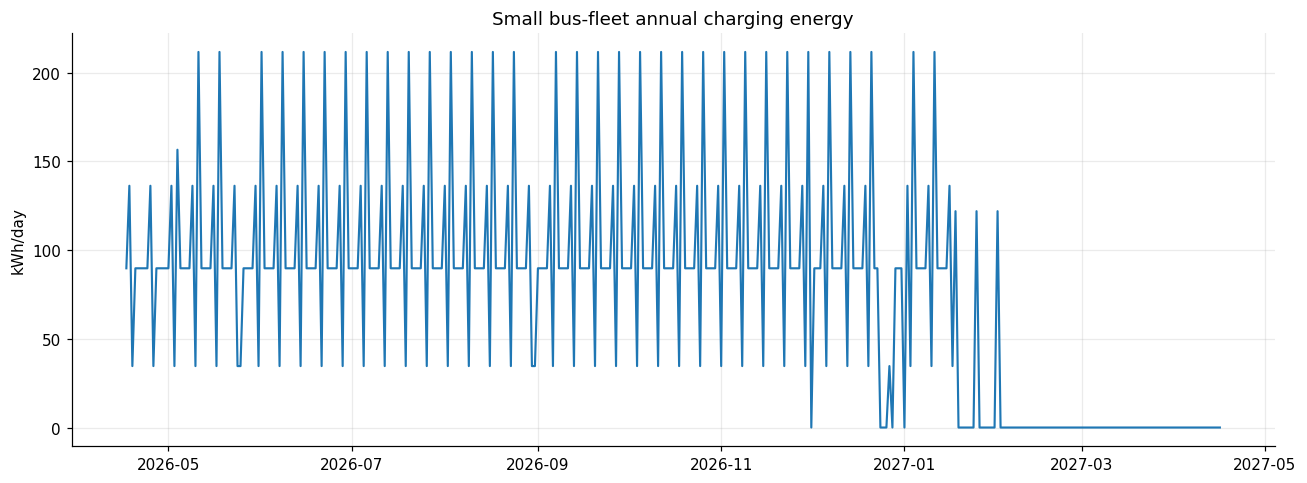

In [5]:
sample_block_ids = candidates.sample(n=min(4, len(candidates)), random_state=MAIN_BUS_ANNUAL_SEED).index.astype(str)
small_fleet_blocks = all_blocks[all_blocks["block_id"].astype(str).isin(sample_block_ids)].copy()
fleet_per_block, fleet_load_kw = simulate_fleet_year(
    small_fleet_blocks,
    service_date_index,
    vehicle_params=vehicle_params,
    vehicle_rng=np.random.default_rng(MAIN_BUS_ANNUAL_SEED + 1),
    start_date=FEED_YEAR_START,
    end_date=FEED_YEAR_END,
    warm_up_days=0,
    progress_interval=4,
)
display(fleet_per_block[[
    "agency_id",
    "service_id",
    "active_days",
    "annual_distance_km",
    "annual_energy_kwh",
    "soc_min",
    "vehicle_gen_model",
]])

daily_energy = fleet_load_kw.sum(axis=1) * STEP_HOURS
per_block_path, load_profile_path = write_annual_results(
    fleet_per_block,
    fleet_load_kw,
    start_date=FEED_YEAR_START,
    end_date=FEED_YEAR_END,
    per_block_path=BUS_ANNUAL_SMOKE_PER_BLOCK_PATH,
    load_profile_path=BUS_ANNUAL_SMOKE_LOAD_PROFILE_PATH,
)
display(
    pd.DataFrame(
        [
            ("per_block_path", str(per_block_path)),
            ("load_profile_path", str(load_profile_path)),
            ("per_block_rows", len(fleet_per_block)),
            ("load_profile_rows", int(fleet_load_kw.shape[0] * fleet_load_kw.shape[1])),
            ("daily_energy_kwh_min", round(float(daily_energy.min()), 2)),
            ("daily_energy_kwh_max", round(float(daily_energy.max()), 2)),
        ],
        columns=["metric", "value"],
    )
)

fig, ax = plt.subplots(figsize=(12, 4.5), dpi=110)
ax.plot(dates, daily_energy, color="tab:blue", lw=1.4)
ax.set(title="Small bus-fleet annual charging energy", ylabel="kWh/day")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## E. Annual Story Slices

,day_type,count,mean,median,min,max
0,weekday,261,82.326439,89.743666,3.996803e-12,211.675436
1,weekend,104,64.415564,34.631282,3.996803e-12,136.255592


,slice,observation
0,weekday_vs_weekend,Weekend active-day charging is 21.8% lower tha...


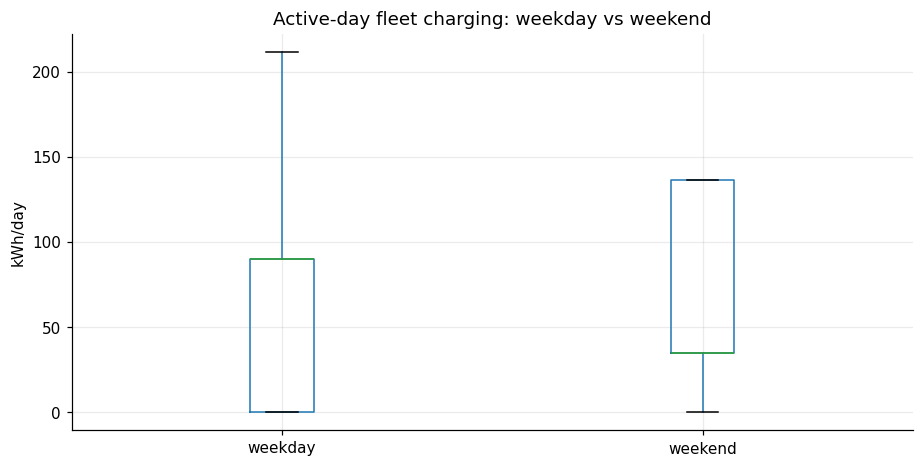

In [6]:
daily_energy_frame = pd.DataFrame(
    {
        "date": dates,
        "daily_total_kwh": daily_energy,
        "day_type": np.where(dates.dayofweek < 5, "weekday", "weekend"),
    }
)
active_daily_energy = daily_energy_frame[daily_energy_frame["daily_total_kwh"].gt(0.0)].copy()
weekday_weekend_summary = (
    active_daily_energy.groupby("day_type")["daily_total_kwh"]
    .agg(["count", "mean", "median", "min", "max"])
    .reset_index()
)
if {"weekday", "weekend"}.issubset(set(weekday_weekend_summary["day_type"])):
    weekday_mean = float(weekday_weekend_summary.loc[weekday_weekend_summary["day_type"].eq("weekday"), "mean"].iloc[0])
    weekend_mean = float(weekday_weekend_summary.loc[weekday_weekend_summary["day_type"].eq("weekend"), "mean"].iloc[0])
    delta_pct = 100.0 * (weekend_mean - weekday_mean) / weekday_mean if weekday_mean else 0.0
    observation = (
        f"Weekend active-day charging is {abs(delta_pct):.1f}% lower than weekday charging."
        if delta_pct < -5.0
        else "The representative service sample does not show a strong weekday/weekend split."
    )
else:
    observation = "The smoke sample does not contain both active weekday and active weekend service days."
display(weekday_weekend_summary)
display(pd.DataFrame([{"slice": "weekday_vs_weekend", "observation": observation}]))

fig, ax = plt.subplots(figsize=(8.5, 4.5), dpi=110)
if not active_daily_energy.empty:
    active_daily_energy.boxplot(column="daily_total_kwh", by="day_type", ax=ax, grid=False)
    ax.set_title("Active-day fleet charging: weekday vs weekend")
    ax.set_xlabel("")
    ax.set_ylabel("kWh/day")
    fig.suptitle("")
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

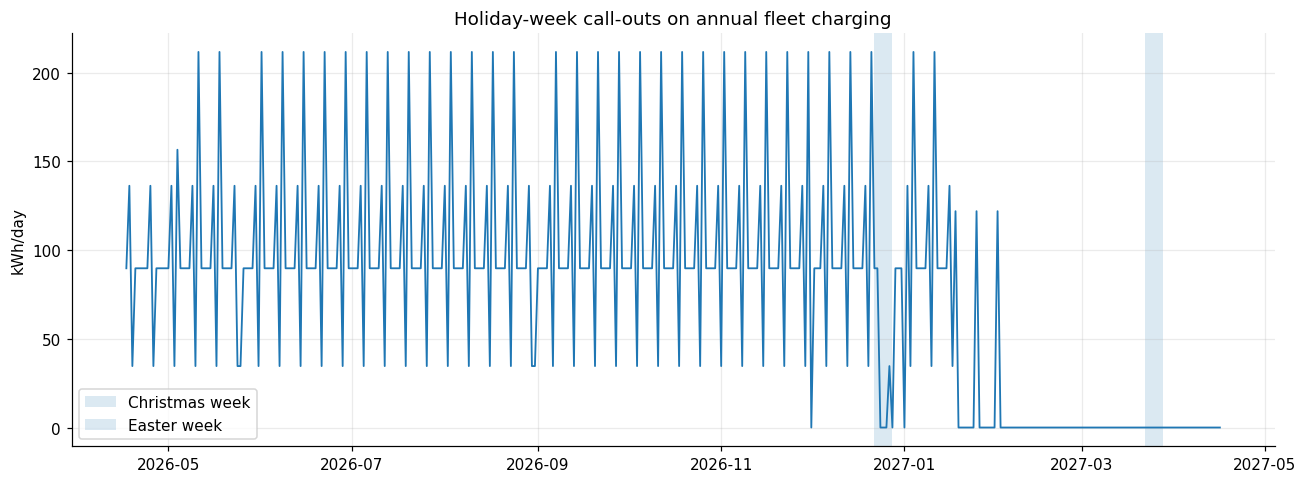

,window,start,end,mean_kwh,vs_feed_mean_pct,interpretation
0,Christmas week,2026-12-22,2026-12-28,30.59,-60.4,visible holiday-week reduction
1,Easter week,2027-03-22,2027-03-28,0.00,-100.0,visible holiday-week reduction


In [7]:
holiday_windows = [
    ("Christmas week", pd.Timestamp("2026-12-22"), pd.Timestamp("2026-12-28")),
    ("Easter week", pd.Timestamp("2027-03-22"), pd.Timestamp("2027-03-28")),
]
baseline_mean = float(daily_energy_frame["daily_total_kwh"].mean())
holiday_rows = []
fig, ax = plt.subplots(figsize=(12, 4.5), dpi=110)
ax.plot(daily_energy_frame["date"], daily_energy_frame["daily_total_kwh"], color="tab:blue", lw=1.2)
for label, start, end in holiday_windows:
    mask = daily_energy_frame["date"].between(start, end)
    window_mean = float(daily_energy_frame.loc[mask, "daily_total_kwh"].mean())
    change_pct = 100.0 * (window_mean - baseline_mean) / baseline_mean if baseline_mean else 0.0
    holiday_rows.append(
        {
            "window": label,
            "start": start.date().isoformat(),
            "end": end.date().isoformat(),
            "mean_kwh": round(window_mean, 2),
            "vs_feed_mean_pct": round(change_pct, 1),
            "interpretation": (
                "visible holiday-week reduction"
                if change_pct < -5.0
                else "no clear holiday reduction in the GTFS representative service assumption"
            ),
        }
    )
    ax.axvspan(start, end, alpha=0.16, label=label)
ax.set(title="Holiday-week call-outs on annual fleet charging", ylabel="kWh/day")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()
display(pd.DataFrame(holiday_rows))

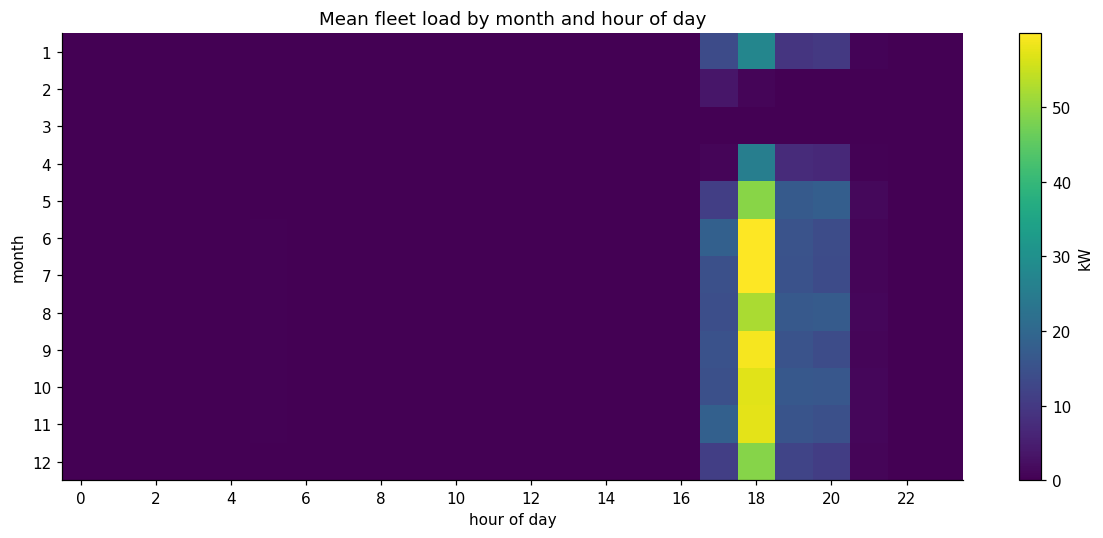

In [8]:
hourly_load_kw = fleet_load_kw.reshape(len(dates), 24, 4).mean(axis=2)
monthly_hourly_load = (
    pd.DataFrame(hourly_load_kw, index=dates, columns=np.arange(24))
    .groupby(lambda value: value.month)
    .mean()
    .reindex(range(1, 13))
)
fig, ax = plt.subplots(figsize=(11, 5), dpi=110)
image = ax.imshow(monthly_hourly_load, aspect="auto", cmap="viridis")
ax.set(
    title="Mean fleet load by month and hour of day",
    xlabel="hour of day",
    ylabel="month",
)
ax.set_xticks(np.arange(0, 24, 2))
ax.set_yticks(np.arange(12))
ax.set_yticklabels(range(1, 13))
fig.colorbar(image, ax=ax, label="kW")
plt.tight_layout()
plt.show()

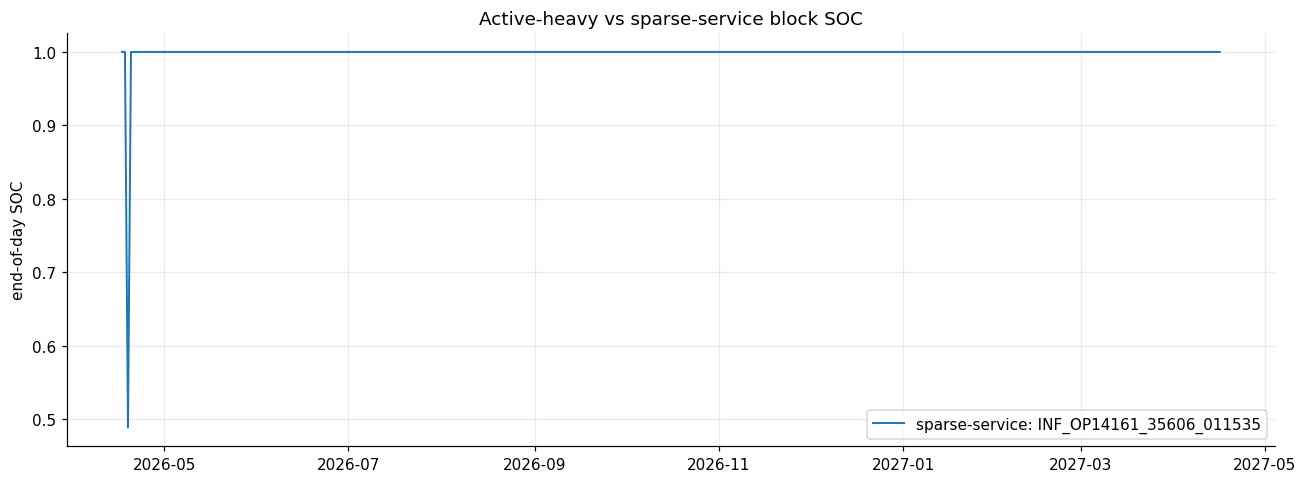

,slice,block_id,active_days,note,soc_min,soc_end,vehicle_gen_model
0,active-heavy,None,0,no matching block in this feed,NaN,NaN,NaN
1,sparse-service,INF_OP14161_35606_011535,1,simulated,0.1873,1.0,BYD ENVIRO


In [9]:
contrast_specs = [
    ("active-heavy", block_stats[block_stats["active_days"].gt(300)].sort_values("active_days", ascending=False)),
    ("sparse-service", block_stats[block_stats["active_days"].between(1, 49)].sort_values("active_days")),
]
contrast_rows = []
fig, ax = plt.subplots(figsize=(12, 4.5), dpi=110)
for label, options in contrast_specs:
    if options.empty:
        contrast_rows.append({"slice": label, "block_id": None, "active_days": 0, "note": "no matching block in this feed"})
        continue
    block_id = str(options.index[0])
    block = all_blocks[all_blocks["block_id"].astype(str).eq(block_id)].copy()
    service_id = str(block["service_id"].iloc[0])
    vehicle = sample_bus_vehicle_specs(
        vehicle_params,
        np.random.default_rng(MAIN_BUS_ANNUAL_SEED + len(contrast_rows) + 10),
        n=1,
    ).iloc[0]
    result = simulate_block_year(
        block,
        service_date_index.get(service_id, ()),
        vehicle,
        FEED_YEAR_START,
        FEED_YEAR_END,
        warm_up_days=0,
    )
    soc_by_day = result["soc"].reshape(len(dates), STEPS_PER_DAY)
    ax.plot(dates, soc_by_day[:, -1], lw=1.3, label=f"{label}: {block_id}")
    contrast_rows.append(
        {
            "slice": label,
            "block_id": block_id,
            "active_days": result["n_active_dates"],
            "soc_min": round(result["soc_min"], 4),
            "soc_end": round(result["soc_end"], 4),
            "vehicle_gen_model": vehicle["gen_model"],
            "note": "simulated",
        }
    )
ax.set(title="Active-heavy vs sparse-service block SOC", ylabel="end-of-day SOC")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()
display(pd.DataFrame(contrast_rows))

## F. Honest Labels

In [10]:
honest_labels = pd.DataFrame(
    [
        ("Calendar window", f"{FEED_YEAR_START} to {FEED_YEAR_END}", "This follows the current GTFS feed-year, not 2025."),
        ("SOC policy", "continuous", "SOC carries across active and inactive days."),
        ("Inactive days", "all-day depot_terminus", "They allow charging recovery between service days."),
        ("Fleet scale", f"{len(sample_block_ids)} sampled blocks", "The notebook is intentionally small; full fleet uses the same simulate_fleet_year API."),
        ("Warm-up", "warm_up_days=0", "Smoke runs stay fast; production annual runs should use WARMUP_DAYS=14 for a steadier first reported day."),
        ("Smoke outputs", f"{BUS_ANNUAL_SMOKE_PER_BLOCK_PATH.name}; {BUS_ANNUAL_SMOKE_LOAD_PROFILE_PATH.name}", "These files are smoke artifacts, not full-fleet production outputs."),
        ("Depot model", "depot_terminus abstraction", "No real depot assignment has been added yet."),
        ("Vehicle assignment", "one sampled EV spec per block", "The sampled bus model remains fixed for that block's feed-year."),
    ],
    columns=["label", "value", "treatment"],
)
display(honest_labels)
print(f"Notebook wall-clock seconds: {time.time() - NOTEBOOK_START:.2f}")

,label,value,treatment
0,Calendar window,2026-04-17 to 2027-04-16,"This follows the current GTFS feed-year, not 2..."
1,SOC policy,continuous,SOC carries across active and inactive days.
2,Inactive days,all-day depot_terminus,They allow charging recovery between service d...
3,Fleet scale,4 sampled blocks,The notebook is intentionally small; full flee...
4,Warm-up,warm_up_days=0,Smoke runs stay fast; production annual runs s...
5,Smoke outputs,bus_annual_smoke_per_block.parquet; bus_annual...,"These files are smoke artifacts, not full-flee..."
6,Depot model,depot_terminus abstraction,No real depot assignment has been added yet.
7,Vehicle assignment,one sampled EV spec per block,The sampled bus model remains fixed for that b...


Notebook wall-clock seconds: 45.81
